In [1]:
year = 2007
month = 1

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import os, pathlib, stat, textwrap

### URLs

In [3]:
Ufiles = "https://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1-daily-gridU"
Vfiles = "https://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1-daily-gridV"
Wfiles = "https://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1-daily-gridW"
Tfiles = "https://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1-daily-gridT"
Sfiles = "https://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1-daily-gridS"
#mesh url
Zgr = "http://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1/glorys12v1-pgnstatics/PSY4V3R1_mesh_zgr.nc"
Hgr = "http://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1/glorys12v1-pgnstatics/PSY4V3R1_mesh_hgr.nc"

### Environment 

In [4]:
os.environ["NETRC"] = "/home/b/b383184/.netrc"

In [5]:
from dask.distributed import Client
client = Client(n_workers=2, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 6,Total memory: 27.94 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34907,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43749,Total threads: 3
Dashboard: http://127.0.0.1:45675/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:37263,


In [6]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


### Mesh

In [7]:
ds_Zgr = xr.open_dataset('../data/Zgr_mesh.nc')
ds_Zgr
# ds_Zgr = ds_Zgr.compute()
# ds_Zgr.to_netcdf('../data/Zgr_mesh.nc')

<xarray.Dataset> Size: 555MB
Dimensions:       (y: 3059, x: 4322, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/13)
    nav_lon       (y, x) float32 53MB ...
    nav_lat       (y, x) float32 53MB ...
    nav_lev       (z) float32 200B ...
    time_counter  (t) float64 8B ...
    mbathy        (t, y, x) int16 26MB ...
    hdept         (t, y, x) float64 106MB ...
    ...            ...
    e3t_ps        (t, y, x) float64 106MB ...
    e3w_ps        (t, y, x) float64 106MB ...
    gdept_0       (t, z) float64 400B ...
    gdepw_0       (t, z) float64 400B ...
    e3t_0         (t, z) float64 400B ...
    e3w_0         (t, z) float64 400B ...
Attributes:
    file_name:            mesh_zgr.nc
    TimeStamp:            03/02/2016 10:24:41 -0000
    Unlimited_Dimension:  t

In [8]:
ds_Hgr = xr.open_dataset('../data/Hgr_mesh.nc')
ds_Hgr
# I want glamT and glamF

<xarray.Dataset> Size: 1GB
Dimensions:       (y: 3059, x: 4322, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/21)
    nav_lon       (y, x) float32 53MB ...
    nav_lat       (y, x) float32 53MB ...
    nav_lev       (z) float32 200B ...
    time_counter  (t) float64 8B ...
    glamt         (t, y, x) float32 53MB ...
    glamu         (t, y, x) float32 53MB ...
    ...            ...
    e1f           (t, y, x) float64 106MB ...
    e2t           (t, y, x) float64 106MB ...
    e2u           (t, y, x) float64 106MB ...
    e2v           (t, y, x) float64 106MB ...
    e2f           (t, y, x) float64 106MB ...
    ff            (t, y, x) float64 106MB ...
Attributes:
    file_name:            mesh_hgr.nc
    TimeStamp:            03/02/2016 10:24:55 -0000
    Unlimited_Dimension:  t

### Functions

In [9]:
lon0, lon1 = -95, 10
lat0, lat1 = -10, 30

# 1) Use T-point lon/lat
lonT = ds_Hgr.glamt.isel(t=0)
latT = ds_Hgr.gphit.isel(t=0)

# 2) Build boolean mask for your box
mask = (lonT >= lon0) & (lonT <= lon1) & (latT >= lat0) & (latT <= lat1)

# 3) Get index ranges
yy, xx = np.where(mask.values)

y0, y1 = int(yy.min()), int(yy.max())
x0, x1 = int(xx.min()), int(xx.max())

x0, x1, y0, y1

# x0=int(ds_Hgr.x.where(ds_Hgr.glamt >= lon0).min())
# x1=int(ds_Hgr.x.where(ds_Hgr.glamt <= lon1).max())

# y0=int(ds_Hgr.y.where(ds_Hgr.gphit >= lat0).min())
# y1=int(ds_Hgr.y.where(ds_Hgr.gphit <= lat1).max())

(2305, 3565, 1374, 1873)

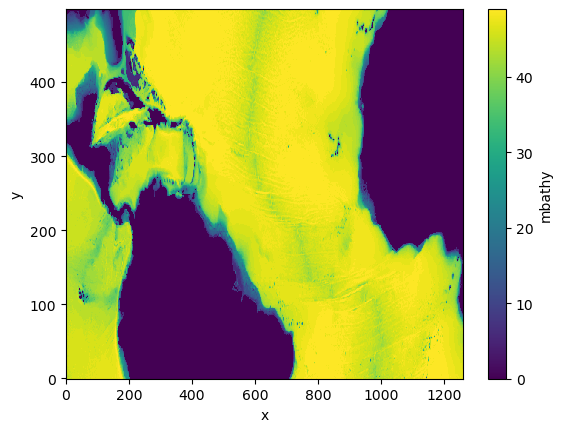

In [10]:
ds_Zgr.isel(x=slice(x0,x1),y=slice(y0,y1),t=0).mbathy.plot()

In [11]:
from datetime import datetime
import calendar

In [12]:
last_day = calendar.monthrange(year, month)[1]
start_date = f"{year}-{month:02d}-01"
end_date = f"{year}-{month:02d}-{last_day:02d}"

In [41]:
def open_subset_var(url, varname, x0, x1, y0, y1, start_date, end_date, engine="pydap"):
    """
    Open an OPeNDAP/THREDDS dataset, sort by time, subset in space/time, and
    return the selected variable as a DataArray.

    url        : str  - dataset URL (OPeNDAP endpoint or local path)
    varname    : str  - variable name to extract (e.g., 'vozocrtx')
    x0,x1,y0,y1: int  - index bounds (inclusive on left, exclusive on right if using slice(x0,x1))
    start_date : str  - ISO date 'YYYY-MM-DD' (or datetime-like)
    end_date   : str  - ISO date 'YYYY-MM-DD' (or datetime-like)
    engine     : str  - 'pydap' or 'netcdf4'
    """
    ds = xr.open_dataset(url, engine=engine, chunks={"time_counter": 1})
    ds = ds.sortby("time_counter")
    da = ds[varname].isel(x=slice(x0, x1), y=slice(y0, y1)).sel(time_counter=slice(start_date, end_date))
    return da

### Data

In [50]:
ds_U = open_subset_var(Ufiles, "vozocrtx", x0, x1+1, y0, y1+1, start_date, end_date, engine="pydap")
ds_V = open_subset_var(Vfiles, "vomecrty", x0, x1+1, y0, y1+1, start_date, end_date, engine="pydap")
ds_W = open_subset_var(Wfiles, "vovecrtz", x0, x1+1, y0, y1+1, start_date, end_date, engine="pydap")
ds_T = open_subset_var(Tfiles, "votemper", x0, x1+1, y0, y1+1, start_date, end_date, engine="pydap")
ds_S = open_subset_var(Sfiles, "vosaline", x0, x1+1, y0, y1+1, start_date, end_date, engine="pydap")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/pydap/handlers/dap.py:143: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


In [43]:
ds_U

<xarray.DataArray 'vozocrtx' (time_counter: 31, deptht: 50, y: 499, x: 1260)> Size: 8GB
dask.array<getitem, shape=(31, 50, 499, 1260), dtype=float64, chunksize=(1, 50, 499, 1260), chunktype=numpy.ndarray>
Coordinates:
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 2007-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 3MB dask.array<chunksize=(499, 1260), meta=np.ndarray>
Attributes:
    units:               m s-1
    valid_min:           -10.0
    valid_max:           10.0
    long_name:           Zonal velocity
    standard_name:       sea_water_x_velocity
    short_name:          vozocrtx
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    associate:           time_counter deptht nav_lat nav_lon
    _ChunkSizes:         [1, 5, 340, 481]

In [44]:
# ds_U = xr.open_dataset(Ufiles, engine="pydap", mask_and_scale=True, decode_cf=True).sortby("time_counter").isel(x=slice(x0,x1),y=slice(y0,y1)).sel(time_counter=slice(start_date,end_date)).vozocrtx
# ds_U

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/pydap/handlers/dap.py:143: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.DataArray 'vozocrtx' (time_counter: 31, deptht: 50, y: 499, x: 1260)> Size: 8GB
[974547000 values with dtype=float64]
Coordinates:
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 2007-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
Attributes:
    units:               m s-1
    valid_min:           -10.0
    valid_max:           10.0
    long_name:           Zonal velocity
    standard_name:       sea_water_x_velocity
    short_name:          vozocrtx
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    associate:           time_counter deptht nav_lat nav_lon
    _ChunkSizes:         [1, 5, 340, 481]

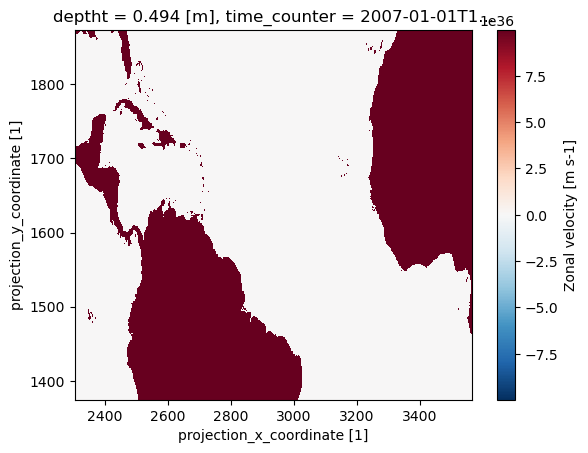

In [47]:
# ds_U.isel(time_counter=0,deptht=0).plot()

In [24]:
# ds_V = xr.open_dataset(Vfiles, engine="pydap").sortby("time_counter").isel(x=slice(x0,x1),y=slice(y0,y1)).sel(time_counter=slice(start_date,end_date)).vomecrty
# ds_V

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/pydap/handlers/dap.py:143: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.DataArray 'vomecrty' (time_counter: 31, deptht: 50, y: 499, x: 1260)> Size: 8GB
[974547000 values with dtype=float64]
Coordinates:
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 2007-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
Attributes:
    units:               m s-1
    valid_min:           -10.0
    valid_max:           10.0
    long_name:           Meridional velocity
    standard_name:       sea_water_y_velocity
    short_name:          vomecrty
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    associate:           time_counter deptht nav_lat nav_lon
    _ChunkSizes:         [1, 5, 340, 481]

In [26]:
# ds_W = xr.open_dataset(Wfiles, engine="pydap").sortby("time_counter").isel(x=slice(x0,x1),y=slice(y0,y1)).sel(time_counter=slice(start_date,end_date)).vovecrtz
# ds_W

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/pydap/handlers/dap.py:143: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.DataArray 'vovecrtz' (time_counter: 31, depthw: 50, y: 499, x: 1260)> Size: 8GB
[974547000 values with dtype=float64]
Coordinates:
  * depthw        (depthw) float32 200B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 2007-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
Attributes:
    units:               m s-1
    valid_min:           -0.01
    valid_max:           0.01
    long_name:           Vertical Velocity
    standard_name:       upward_sea_water_velocity
    short_name:          vovecrtz
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    associate:           time_counter depthw nav_lat nav_lon
    _ChunkSizes:         [1, 5, 340, 481]

In [29]:
# ds_T = xr.open_dataset(Tfiles, engine="pydap").sortby("time_counter").isel(x=slice(x0,x1),y=slice(y0,y1)).sel(time_counter=slice(start_date,end_date)).votemper
# ds_T

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/pydap/handlers/dap.py:143: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.DataArray 'votemper' (time_counter: 31, deptht: 50, y: 499, x: 1260)> Size: 8GB
[974547000 values with dtype=float64]
Coordinates:
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 2007-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
Attributes:
    units:               degree_Celsius
    valid_min:           -20.0
    valid_max:           42.0
    long_name:           Temperature
    standard_name:       sea_water_potential_temperature
    short_name:          votemper
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    associate:           time_counter deptht nav_lat nav_lon
    _ChunkSizes:         [1, 5, 340, 481]

In [32]:
# ds_S = xr.open_dataset(Sfiles, engine="pydap").sortby("time_counter").isel(x=slice(x0,x1),y=slice(y0,y1)).sel(time_counter=slice(start_date,end_date)).vosaline
# ds_S

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/pydap/handlers/dap.py:143: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.DataArray 'vosaline' (time_counter: 31, deptht: 50, y: 499, x: 1260)> Size: 8GB
[974547000 values with dtype=float64]
Coordinates:
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 2007-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
Attributes:
    units:               PSU
    valid_min:           0.0
    valid_max:           50.0
    long_name:           Salinity
    standard_name:       sea_water_salinity
    short_name:          vosaline
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    associate:           time_counter deptht nav_lat nav_lon
    _ChunkSizes:         [1, 5, 340, 481]

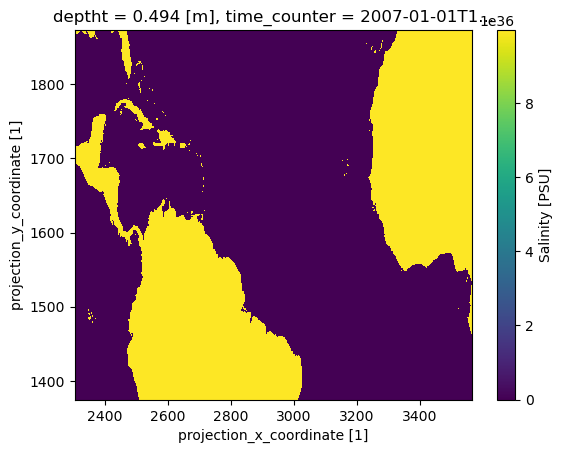

In [40]:
# ds_S.isel(time_counter=0,deptht=0).where(ds_S.isel(time_counter=0,deptht=0) !=9.96920997e+36,np.nan).plot() 

In [49]:
# da = ds_S
# fill = getattr(da, "_FillValue", 9.969209968386869e+36)
# da = da.where(da != fill)  # keep valid values, others become NaN
# da.plot()

HTTPError: HTTP Error occurred 403 Client Error: Forbidden for url: https://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1-daily-gridS.dods?vosaline.vosaline%5B5113:1:5143%5D%5B0:1:49%5D%5B1374:1:1872%5D%5B2305:1:3564%5D - Failed to fetch data from `https://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1-daily-gridS.dods?vosaline.vosaline[5113:1:5143][0:1:49][1374:1:1872][2305:1:3564]`

In [33]:
#  # triggers data transfer
# ds_S.nbytes / 1024**3  # GB actually held in memory

7.260940968990326